# eq_Taux_bias: Zonal structure of time-mean Zonal Mean Stress (Taux) in the equatorial Pacific

Computes the zonal root mean square error (RMSE) of equatorial Pacific (150°E-90°W) climatological (time and meridional 5°S-5°N average) zonal wind stress (Taux) between model and observations

## Datasets Used for Zonal Mean Stress Comparison

The following reference reanalysis datasets are used to evaluate the model simulations:

- **TropFlux (1979-2018)**: The primary dataset for comparison. TropFlux provides estimates of air-sea heat, momentum, and freshwater fluxes over the tropical oceans, designed specifically for tropical climate analysis by combining satellite data and in-situ measurements.

Additional reanalysis datasets used for comparison include:
- **20CRv2 (1871-2012)**: The 20th Century Reanalysis provides global atmospheric data based on surface pressure observations and historical data assimilation, offering a long-term record of climate and weather variability spanning over 140 years.
- **ERA-Interim (1979-2018)**: The European Centre for Medium-Range Weather Forecasts (ECMWF) reanalysis dataset delivers high-resolution atmospheric and surface variables using modern assimilation techniques, often used for climate and weather analysis.
- **NCEP2 (1979-2018)**: The second-generation reanalysis from the National Centers for Environmental Prediction (NCEP), offering improved global atmospheric and surface data by correcting known issues from the earlier version and assimilating more recent observations.

## Dask Cluster 

Start a cluster with multiple cores 

In [1]:
from dask.distributed import Client, progress
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=67, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32827 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/32827/status,
Dashboard: /proxy/32827/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45767,Workers: 0
Dashboard: /proxy/32827/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36787,Total threads: 4
Dashboard: /proxy/34025/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:38405,


## Datasets

In [2]:
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:639: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, rem

In [3]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='tauu',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

obs_datasets = {
 "ERA-Interim": 
     Dataset(
     short_name='tauu',
     dataset='ERA-Interim',
     mip="Amon",
     project='OBS6',
     type='reanaly',
     timerange="19790101/20190101",
     tier=3),
# "NOAA-CIRES-20CR-V2": 
#     Dataset(
#     short_name='tauu',
#     dataset='NOAA-CIRES-20CR-V2',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="187101/201212",
#     tier=2),
}



## Add Ancillary files

In [4]:
for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [5]:
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_valid

In [6]:
import iris
from iris.util import equalise_attributes

#filename  = "/scratch/p66/yz9299/MOPPeR_outputs/CMIP6/CMIP/CSIRO/ACCESS-ESM1-6/piControl-spinup/r1i1p1f1/Amon/ts/gn/v20250801/*nc"
filename = "/scratch/p66/fc6164/MOPPeR/tauu_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc"

esm16cube = iris.load_cube(filename,'surface_downward_eastward_stress')
#equalise_attributes(esm16cube)

esm16cube_concat = esm16cube#.concatenate()


print(esm16cube_concat)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'tauu'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'tauu'
  warnings.warn(


surface_downward_eastward_stress / (Pa) (longitude: 192; latitude: 145; time: 6000)
    Dimension coordinates:
        longitude                                 x              -          -
        latitude                                  -              x          -
        time                                      -              -          x
    Cell methods:
        0                               area: time: mean
    Attributes:
        Conventions                     'CF-1.7 CMIP-6.2'
        STASH                           m01s03i460
        activity_id                     'CMIP'
        branch_method                   'standard'
        branch_time_in_child            0.0
        branch_time_in_parent           54786.0
        comment                         'Downward eastward wind stress at the surface'
        creation_date                   '2025-08-27T06:12:37Z'
        creator_email                   'felicity.chun@anu.edu.au'
        creator_name                    'felicit

In [7]:
from esmvalcore.preprocessor import annual_statistics
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import axis_statistics
from esmvalcore.preprocessor import mask_landsea

In [8]:
def preproc1(cube):
    nino3_ep_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=1979, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)        
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_ep_region)
    cube = axis_statistics(cube, operator="mean", axis="y")
    cube = convert_units(cube, units="1e-3 N/m2")
    return cube

def preproc2(cube):
    nino3_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=1979, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)        
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube = convert_units(cube, units="1e-3 N/m2")
    return cube

def preproc1_pi(cube, start, end):
    nino3_ep_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_ep_region)
    cube = axis_statistics(cube, operator="mean", axis="y")
    cube = convert_units(cube, units="1e-3 N/m2")
    return cube

def preproc2_pi(cube, start, end):
    nino3_latext_region = {"start_longitude": 140., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = mask_landsea(cube, mask_out="land") #uses shapefiles, ancVariable, land_area_fraction
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube = convert_units(cube, units="1e-3 N/m2")
    return cube


In [9]:
model_ctrldatasets_prep1 = {name: preproc1_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep1 = preproc1_pi(esm16cube,1800,2000)
obs_datasets_prep1 = {name: preproc1(dataset) for name, dataset in obs_datasets.items()}

model_ctrldatasets_prep2 = {name: preproc2_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep2 = preproc2_pi(esm16cube,1800,2000)
obs_datasets_prep2 = {name: preproc2(dataset) for name, dataset in obs_datasets.items()}

# Diagnostics Level 1


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


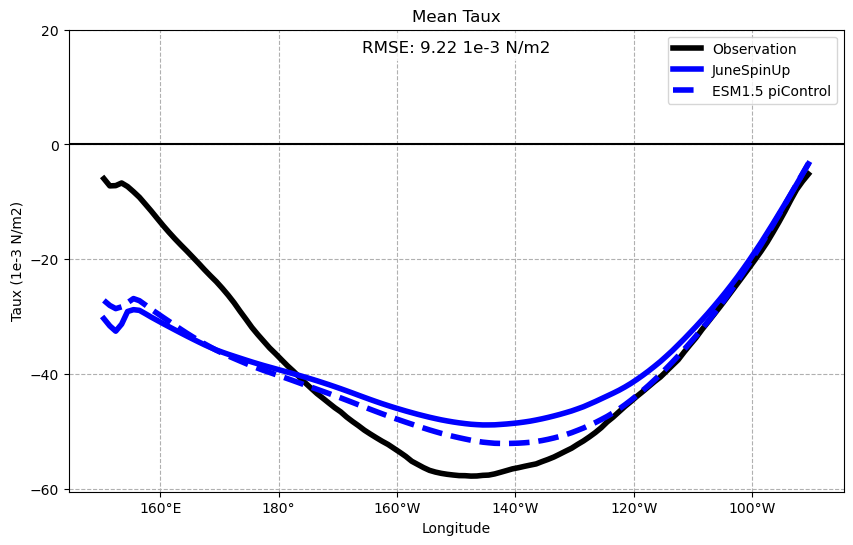

In [10]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import numpy as np

# Function to format x-axis labels with degree symbols and N/S
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

plt.figure(figsize=(10, 6))

obs_data = obs_datasets_prep1["ERA-Interim"]
model_ctrldata = model_ctrldatasets_prep1["ACCESS-ESM1-5"]
model_data = model_datasets_prep1#["ACCESS-ESM1-5"]

# Plot observation data in black
qplt.plot(obs_data, color='black', label='Observation', linewidth=4)

# Plot model data in blue
qplt.plot(model_data, color='blue', label='JuneSpinUp', linewidth=4)
qplt.plot(model_ctrldata, color='blue', label='ESM1.5 piControl', linewidth=4,linestyle='--')

rmse = np.sqrt(np.mean((obs_data.data - model_data.data) ** 2))

# Adding labels and title
plt.xlabel('Longitude')
plt.ylabel('Taux (1e-3 N/m2)')
plt.title('Mean Taux')
plt.grid(linestyle='--')
plt.yticks(np.arange(-60,21, step=20))
plt.axhline(y=0, color='black')

# Adding RMSE text on top of the plot
plt.text(0.5, 0.95, f'RMSE: {rmse:.2f} 1e-3 N/m2', fontsize=12, ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Setting custom x-axis formatter
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))

# Adding a legend
plt.legend()

# Display the plot
plt.show()

Figure 1: Zonal bias in the structure of zonal wind stress (Taux) across the equatorial Pacific (averaged between 5°S–5°N), primarily highlighting the trade winds bias (typically weaker circulation in the central Pacific and stronger in the western Pacific). The black curve represents the reference data, and the blue curve represents the model data. The metric displayed is the zonal RMSE between the model and reference curves.

# Diagnostics Level 2


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


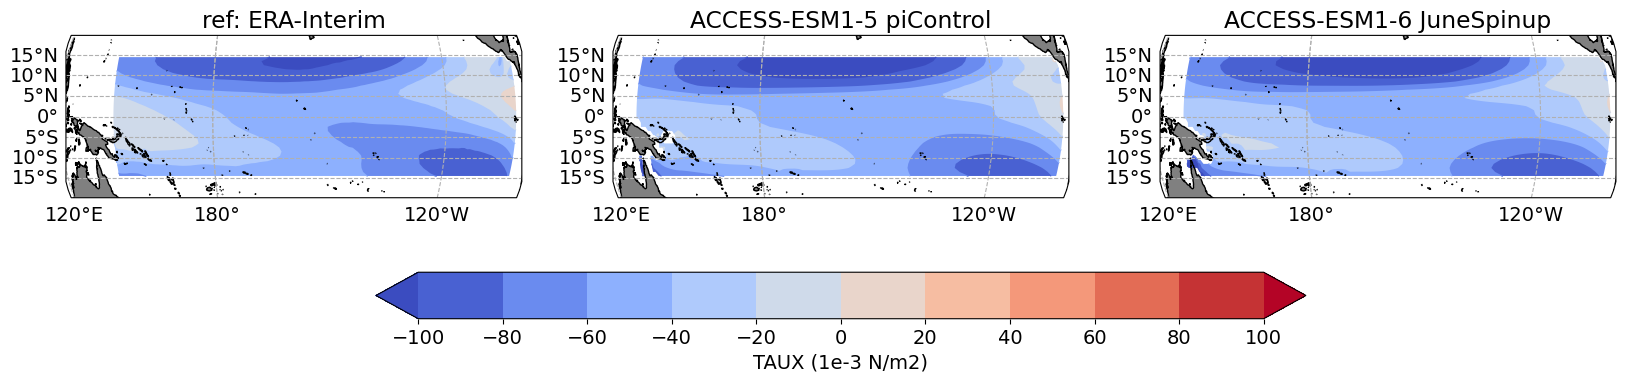

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Importing numpy for linear space creation
import numpy as np

import iris
import iris.plot as iplt

plt.rcParams.update({'font.size': 14})

obs_data = obs_datasets_prep2["ERA-Interim"]
model_ctrldata = model_ctrldatasets_prep2["ACCESS-ESM1-5"]
model_data = model_datasets_prep2#["ACCESS-ESM1-5"]
vmin=-100
vmax=100
nlevels=11
levels = np.linspace(vmin, vmax, nlevels)

# Use the coolwarm colormap
cmap = plt.get_cmap('coolwarm')

# Create a large figure
fig = plt.figure(figsize=(20, 10))  # Adjusted for full width

# Center the map on the Pacific Ocean (roughly around 180° longitude)
proj = ccrs.Orthographic(central_longitude=-160, central_latitude=0)

# Define the normalization for the color scale with range of -100 to 100
norm = mcolors.Normalize(vmin=-100, vmax=100)



# Plot #1: contourf with axes longitude from -180 to 180
ax1 = plt.subplot(131, projection=proj)
cf1 = iplt.contourf(obs_data, cmap=cmap,  vmin=vmin,vmax=vmax,levels=levels,extend='both')
ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax1.coastlines()
ax1.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax1.set_title("ref: ERA-Interim")

# Add gridlines for latitude and longitude
gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

# Plot #2: contourf with axes longitude from 0 to 360
ax2 = plt.subplot(132, projection=proj)
cf2 = iplt.contourf(model_ctrldata, cmap=cmap,  vmin=vmin,vmax=vmax,levels=levels,extend='both')
ax2.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax2.coastlines()
ax2.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax2.set_title("ACCESS-ESM1-5 piControl")

# Add gridlines for latitude and longitude
gl2 = ax2.gridlines(draw_labels=True, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False


# Plot #3: contourf with axes longitude from 0 to 360
ax3 = plt.subplot(133, projection=proj)
cf3 = iplt.contourf(model_data, cmap=cmap,  vmin=vmin,vmax=vmax,levels=levels,extend='both')
ax3.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax3.coastlines()
ax3.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax3.set_title("ACCESS-ESM1-6 JuneSpinup")
# Add gridlines for latitude and longitude
gl3 = ax3.gridlines(draw_labels=True, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False


# Add a single colorbar at the bottom
# NOTE: The colorbar will be based on cf2, which already has the correct normalization applied.
cbar = fig.colorbar(cf3, ax=[ax1, ax2,ax3], orientation='horizontal', pad=0.15, shrink=0.6)
cbar.set_label('TAUX (1e-3 N/m2)')
#cbar.set_clim(-100, 100)
cbar.set_ticks(cf3.levels)

plt.subplots_adjust(bottom=0.3)  # Further adjust bottom margin to fit the colorbar
plt.show()


Figure 2: Time-mean zonal wind stress (Taux) bias in the equatorial Pacific, illustrating the southeasterly and northeasterly trade winds that form the surface branch of the Walker circulation. The left map shows the reference data, while the right map displays the model data.